In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import statsmodels.formula.api as smf

# News-driven market regimes: A study on the effects of intraday market moving event arrivals on trading volume and volatility

## Data loading

In [5]:
# Market data
QQQ_5min = pd.read_csv(r'C:\Users\Raymon\QF632/Project/Aryan/fds-indx-data/indx_data/QQQ_5min.csv')
QQQ_vol = pd.read_csv(r'C:\Users\Raymon\QF632/Project/Aryan/fds-indx-data/indx_data/QQQ_volatility.csv')

In [6]:
# Tweet data
tweet_data = pd.read_csv(r'C:\Users\Raymon\QF632\Project\Aryan\fds-indx-data\Tweet data\firstsquawk_market_hours.csv')

## Main study

### Definition of an event

#### Data cleaning

Dataset contains several "ghost" rows containing price data when the market was closed. We have to delete those rows before proceeding

In [11]:
def delete_ghost_rows(df):
    """
    Dynamically identifies early-close days across ALL years in the dataset
    by checking where true market activity ends at 13:00, then purges 
    any post-13:00 ghost records on those dates.
    """
    cleaned_df = df.copy()
    cleaned_df['datetime'] = pd.to_datetime(cleaned_df['datetime'])
    
    # Extract temporal components
    months = cleaned_df['datetime'].dt.month
    days = cleaned_df['datetime'].dt.day
    times = cleaned_df['datetime'].dt.time
    day_of_weeks = cleaned_df['datetime'].dt.dayofweek
    
    cutoff_time = pd.to_datetime("13:00:00").time()
    
    # Standard US Market early close rules
    is_july_3rd = (months == 7) & (days == 3)
    is_black_friday = (months == 11) & (day_of_weeks == 4) & (days >= 23) & (days <= 29)
    is_christmas_eve = (months == 12) & (days == 24)
    
    # Target early close dates AND any time starting FROM 13:00:00 onwards
    is_early_close_date = is_july_3rd | is_black_friday | is_christmas_eve
    is_ghost_row = is_early_close_date & (times >= cutoff_time)  # Changed to >=
    
    num_ghosts = is_ghost_row.sum()
    
    if num_ghosts > 0:
        cleaned_df = cleaned_df[~is_ghost_row].reset_index(drop=True)
        print(f"🧹 Purged exactly {num_ghosts} ghost rows (including the 13:00:00 bars) across the timeline.")
    else:
        print("✅ Clean dataset. No ghost rows detected.")
        
    return cleaned_df

In [12]:
QQQ_5min = delete_ghost_rows(QQQ_5min)

🧹 Purged exactly 216 ghost rows (including the 13:00:00 bars) across the timeline.


#### Feature engineering

**Feature engineering**

The key point of this section is define criteria to isolate tweets that are classified as events using the data available to us i.e. price change, volatility, and trading volume.

Features:

-  Absolute log returns: Focuses purely on the magnitude of price disruptions. It treats spikes of a particular percentage as drops of the same percentage with equal weightage.
$$R_t = \left| \ln\left(\frac{\text{Close}_t}{\text{Open}_t}\right) \right|$$

-  Parkinson volatility: Captures intra period volatility i.e. price swing within the 5 min window, where standard rolling volatility would only capture volatility in close to close returns.
$$\text{Vol}_t = \frac{\left(\ln(\text{High}_t) - \ln(\text{Low}_t)\right)^2}{4 \ln 2}$$

-  Volume: Raw volume is used as a proxy for market-moving institutional re-positioning.

**Shock index**

Using fixed criteria to define events is **not a good solution given the nonstationary nature of markets**, even within the same day (e.g. volume and volatility will be higher during market open and market close, which may falsely be identified as events if we use a broad average). Therefore, features will be constructed and standardised into Z-scores with regard to **previous observations of that same 5 minute window** over the **past 20 days**. Thus, the feature Z-score for a particular 5 minute interval is a representation of how many standard deviations away from the mean over past 20 observations of that particular 5 minute interval. These Z-scores are then combined into a Shock Index which will be used in the ultimate determination of whether a movement is an event.

$$\text{Shock Index} = \sqrt{(Z_{\text{Return}})^2 + (Z_{\text{Parkinson}})^2 + (Z_{\text{Volume}})^2}$$

 
- 5 minute intervals with low Shock index Shock Index implies that it is not statistically likely for an event to have occurred.

- 5 minute intervals with higher Shock index implies that it is likely that an event has occurred given the distribution of the past 20 observations.

In [15]:
def compute_market_shocks(qqq_df, window_days=20):
    """
    This function executes feature engineering with log-transforms on volatility and volume,
    calculates rolling historical Z-scores, and computes an asymmetric, volume-heavy Shock Index.
    
    Input(s): qqq_df: DataFrame containing qqq OHLCV data.
              window_days: lookback period for rolling z-score calculation. Default is 20 
    Output(s): df: DataFrame with prices, engineered features, and Shock index for each interval 
    """
    df = qqq_df.copy()

    # datetime validation
    df["datetime"] = pd.to_datetime(df["datetime"])
    df = df.sort_values("datetime").reset_index(drop=True)

    # Feature engineering: log absolute returns, log volume, and log parkinsons volatility
    df["log_ret"] = np.abs(np.log(df["close"]) - np.log(df["open"]))
    
    # Log-transform raw volume to stabilize tail variance
    df["log_volume"] = np.log(df["volume"] + 1e-8)
    
    # Log-transform raw Parkinson's volatility
    df["park_vol_raw"] = ((np.log(df["high"]) - np.log(df["low"])) ** 2) / (4 * np.log(2))
    df["park_vol"] = np.log(df["park_vol_raw"] + 1e-8)

    # Isolate time and date of each interval for benchmarking / z-score calculation
    df["time_id"] = df["datetime"].dt.time
    df["date_id"] = df["datetime"].dt.date

    df["z_ret"] = np.nan
    df["z_vol"] = np.nan
    df["z_park"] = np.nan

    # Rolling Window Z-Score Calculation across matched 5-minute intervals
    for metric in ["log_ret", "log_volume", "park_vol"]:
        pivot_df = df.pivot(
            index="date_id", columns="time_id", values=metric
        ).sort_index()

        # Compute rolling mean and std over previous windows without data leakage
        rolling_mean = pivot_df.shift(1).rolling(window=window_days).mean()
        rolling_std = pivot_df.shift(1).rolling(window=window_days).std()

        # Unpivot back to align with original dataframe structure
        mean_flat = rolling_mean.unstack().reset_index(name="mean_val")
        std_flat = rolling_std.unstack().reset_index(name="std_val")

        df = df.merge(
            mean_flat, on=["time_id", "date_id"], how="left"
        ).merge(std_flat, on=["time_id", "date_id"], how="left")

        z_col = (
            "z_ret"
            if metric == "log_ret"
            else ("z_vol" if metric == "log_volume" else "z_park")
        )
        
        # Original Z-score calculation with standard 0 to NaN substitution
        df[z_col] = (df[metric] - df["mean_val"]) / df["std_val"].replace(0, np.nan)

        df.drop(columns=["mean_val", "std_val"], inplace=True)

    # Computation of Asymmetric Shock Index (Weighted Euclidean Distance)
    # Weights follow the rule: volume (0.50) > return (0.35) > parkinsons_vol (0.15)
    # Squaring the weights inside the radical preserves the geometric intent of the norm.
    df['shock_index'] = np.sqrt(
        (0.50 * df['z_vol'])**2 + 
        (0.35 * df['z_ret'])**2 + 
        (0.15 * df['z_park'])**2
    )

    return df

In [16]:
QQQ_processed = compute_market_shocks(QQQ_5min)

#### Analyses of shock index distribution

In [18]:
QQQ_processed['shock_index'].describe()

count    25698.000000
mean         0.612789
std          0.466019
min          0.015536
25%          0.335581
50%          0.509200
75%          0.762041
max         16.799369
Name: shock_index, dtype: float64

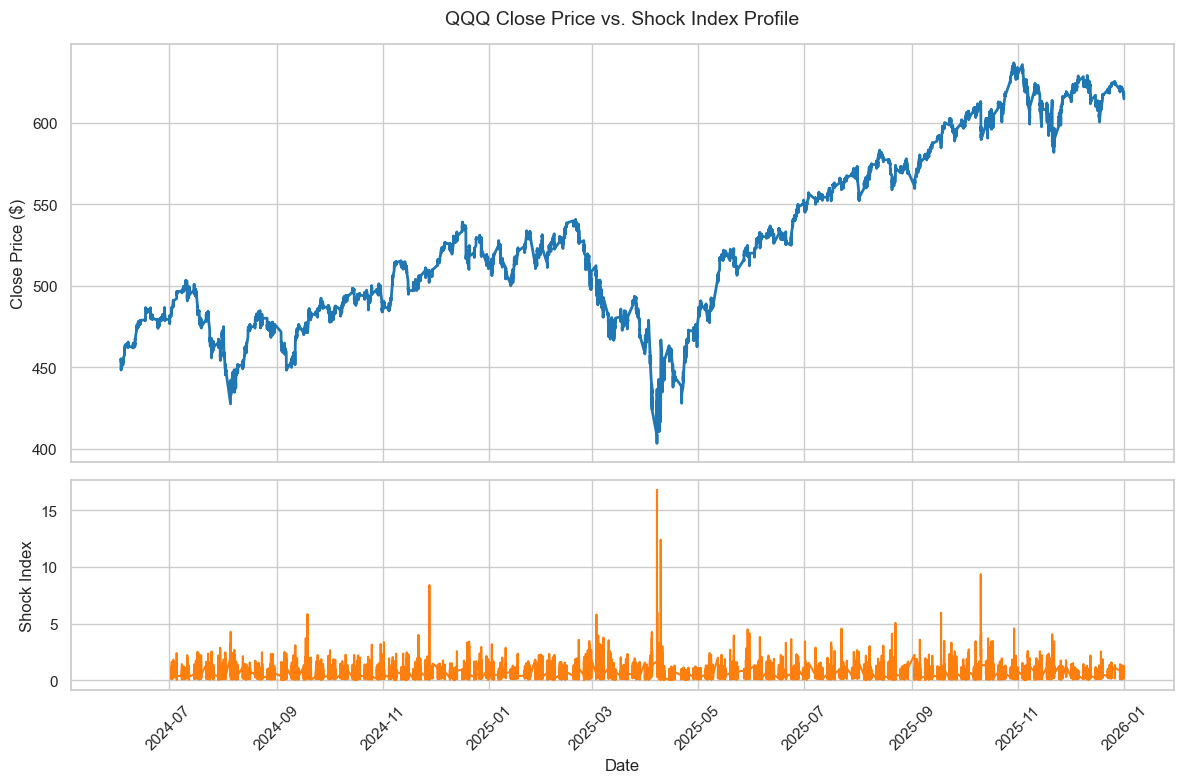

In [19]:
sns.set_theme(style="whitegrid")

# 3. Create the 2-row subplot configuration
fig, (ax1, ax2) = plt.subplots(
    nrows=2, 
    ncols=1, 
    sharex=True, 
    figsize=(12, 8), 
    gridspec_kw={'height_ratios': [2, 1]}
)

# 4. Plot 'close' on the top subplot (ax1)
sns.lineplot(
    data=QQQ_processed, 
    x='datetime', 
    y='close', 
    ax=ax1, 
    color='#1f77b4', 
    linewidth=2
)
ax1.set_title('QQQ Close Price vs. Shock Index Profile', fontsize=14, pad=15)
ax1.set_ylabel('Close Price ($)', fontsize=12)

# 5. Plot 'shock_index' on the bottom subplot (ax2)
sns.lineplot(
    data=QQQ_processed, 
    x='datetime', 
    y='shock_index', 
    ax=ax2, 
    color='#ff7f0e', 
    linewidth=1.5
)
ax2.set_ylabel('Shock Index', fontsize=12)
ax2.set_xlabel('Date', fontsize=12)

# 6. Rotate the date labels slightly so they don't overlap
plt.xticks(rotation=45)

# 7. Fine-tune layout and display
plt.tight_layout()
plt.show()

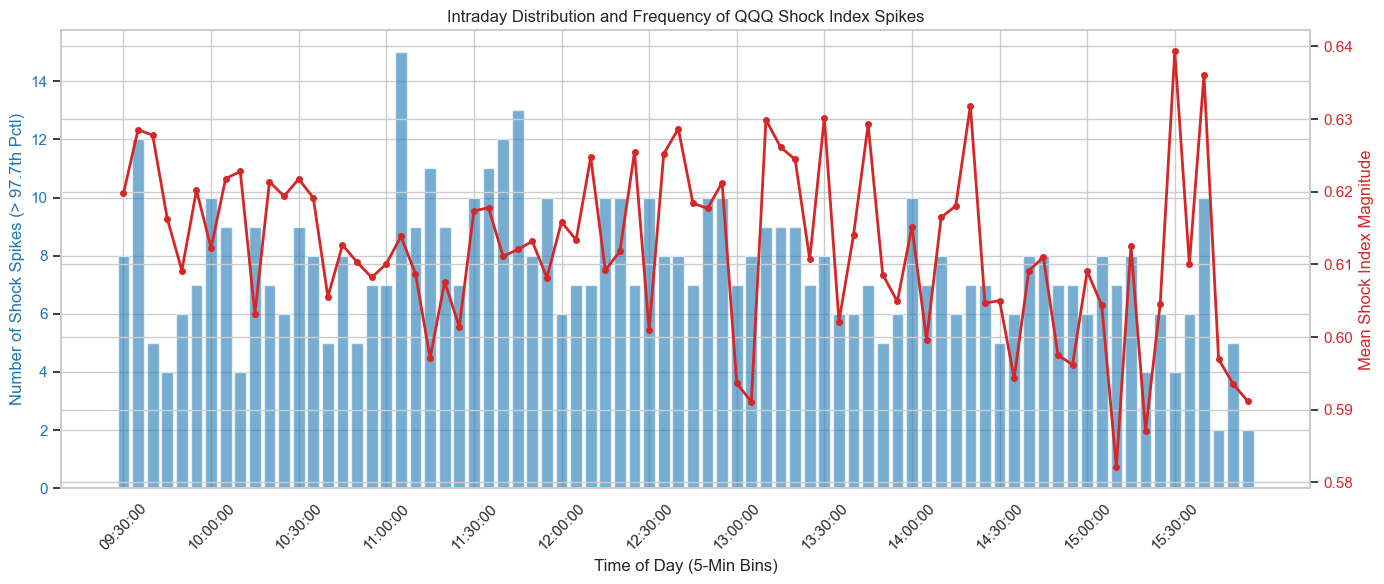

In [20]:
QQQ_processed['5min_interval'] = QQQ_processed['datetime'].dt.floor('5min').dt.time

# 2. Define what constitutes a "spike" (e.g., top 5% of all shocks)
shock_threshold = QQQ_processed['shock_index'].quantile(0.977)

# 3. Aggregate by interval
# We track the mean intensity, the maximum shock, and the count of actual spikes
intraday_dist = QQQ_processed.groupby('5min_interval').agg(
    mean_shock=('shock_index', 'mean'),
    max_shock=('shock_index', 'max'),
    spike_count=('shock_index', lambda x: (x > shock_threshold).sum())
).reset_index()

# Convert time objects to strings for cleaner plotting on the x-axis
intraday_dist['time_str'] = intraday_dist['5min_interval'].astype(str)

# Filter for market hours (e.g., 09:30 to 16:00) to keep the chart clean, 
# or keep the full 24h if you're looking at overnight/pre-market shocks.
market_hours = intraday_dist[
    (intraday_dist['5min_interval'] >= pd.to_datetime('09:30').time()) & 
    (intraday_dist['5min_interval'] <= pd.to_datetime('16:00').time())
]

fig, ax1 = plt.subplots(figsize=(14, 6))

# Plot 1: Frequency of spikes (Bar chart)
color = 'tab:blue'
ax1.set_xlabel('Time of Day (5-Min Bins)')
ax1.set_ylabel('Number of Shock Spikes (> 97.7th Pctl)', color=color)
bars = ax1.bar(market_hours['time_str'], market_hours['spike_count'], color=color, alpha=0.6)
ax1.tick_params(axis='y', labelcolor=color)

# Rotate x-labels and only show every Nth label to avoid crowding
ax1.set_xticks(market_hours['time_str'][::6]) 
ax1.tick_params(axis='x', rotation=45)

# Plot 2: Average intensity of shocks (Line chart)
ax2 = ax1.twinx()  
color = 'tab:red'
ax2.set_ylabel('Mean Shock Index Magnitude', color=color)
ax2.plot(market_hours['time_str'], market_hours['mean_shock'], color=color, linewidth=2, marker='o', markersize=4)
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Intraday Distribution and Frequency of QQQ Shock Index Spikes')
fig.tight_layout()
plt.show()

Left y axis: number of times the a shock index above 95th percentile occurs in this interval.

Right y axis: mathematical average / mean value of the shock index during that 5 minute window

Interpretation:

- High bars + high line: Structurally volatile period where shocks happen frequently. When shocks have happened here, they were severe.
- High bars + low line: Market frequently crosses the threshold here but only by a small margin. This is a period of regular, minor turbulence or algo rebalancing.
- Low bars + high line: Shocks rarely happened at this time of day, but the dataset includes one or two massive anomalies which drag the average up. 

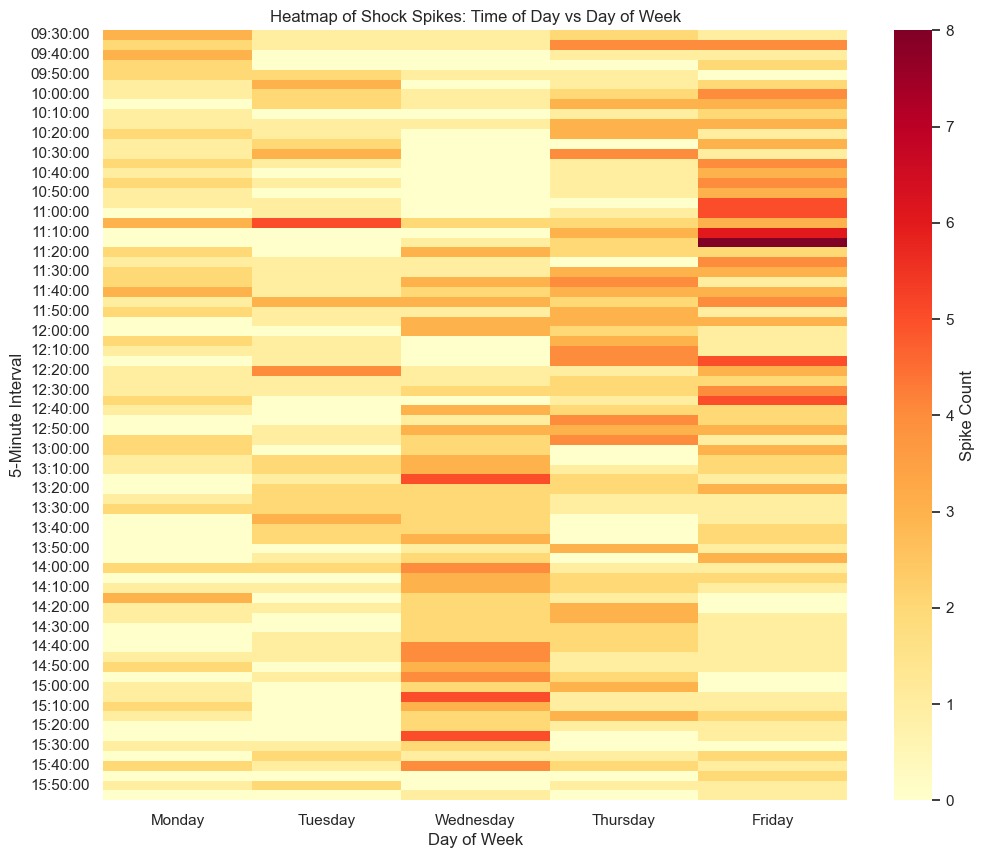

In [22]:
# Extract day of the week
QQQ_processed['day_of_week'] = QQQ_processed['datetime'].dt.day_name()

# Create a pivot table counting spikes
heatmap_data = QQQ_processed.pivot_table(
    index='5min_interval',
    columns='day_of_week',
    values='shock_index',
    aggfunc=lambda x: (x > shock_threshold).sum()
)

# Reorder columns to standard calendar order
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday']
heatmap_data = heatmap_data.reindex(columns=days_order)

# Filter index for regular trading hours for a clearer view
market_heatmap = heatmap_data.loc[
    (heatmap_data.index >= pd.to_datetime('09:30').time()) & 
    (heatmap_data.index <= pd.to_datetime('16:00').time())
]

plt.figure(figsize=(12, 10))
sns.heatmap(market_heatmap, cmap='YlOrRd', cbar_kws={'label': 'Spike Count'})
plt.title('Heatmap of Shock Spikes: Time of Day vs Day of Week')
plt.ylabel('5-Minute Interval')
plt.xlabel('Day of Week')
plt.show()

#### Event threshold selection

Use an elbow curve to visualise how various shock-index thresholds would affect the number of events identified

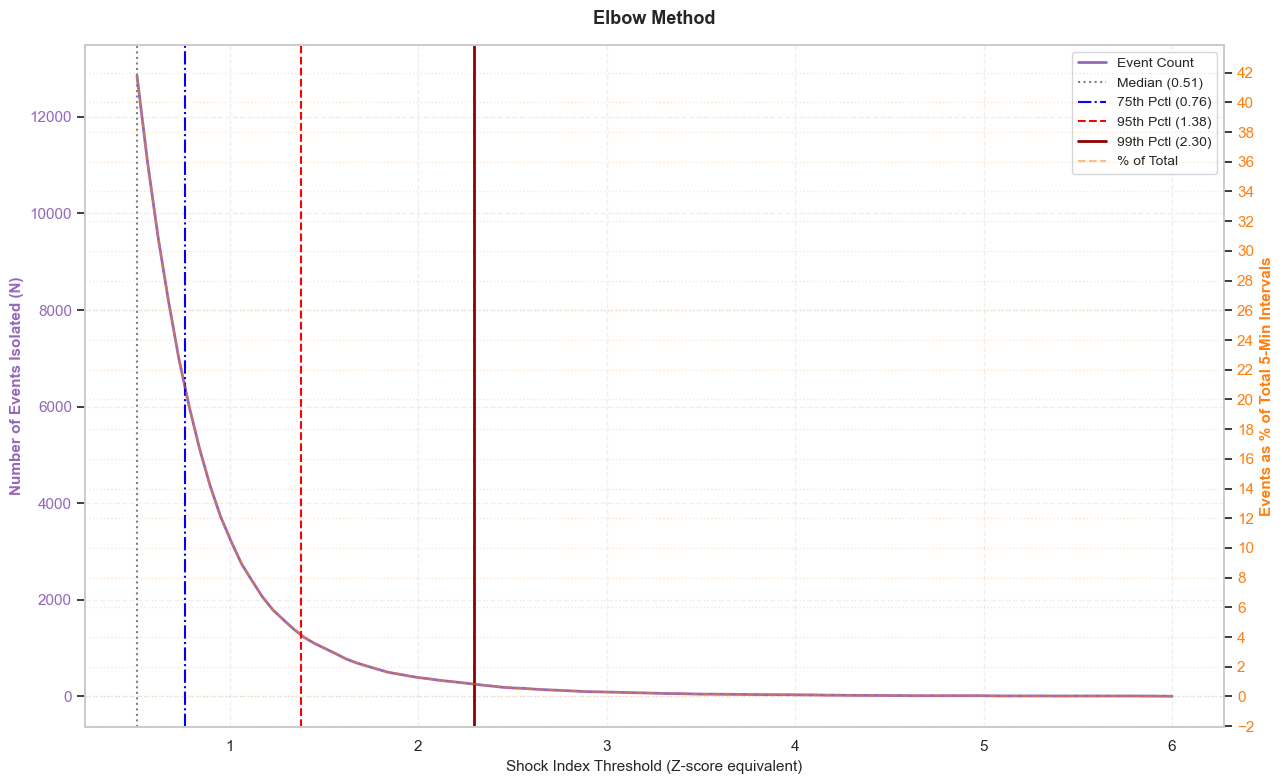

In [25]:
# 1. Calculate the exact empirical percentiles from your shock_index column
median_val = QQQ_processed['shock_index'].quantile(0.50)
p75_val = QQQ_processed['shock_index'].quantile(0.75)
p95_val = QQQ_processed['shock_index'].quantile(0.95)
p99_val = QQQ_processed['shock_index'].quantile(0.99)

# 2. Define range of thresholds to test
min_thresh = min(1.0, median_val)
max_thresh = max(6.0, p99_val + 1.0)
threshold_options = np.linspace(min_thresh, max_thresh, 100)
total_intervals = len(QQQ_processed)

# 3. Calculate absolute counts and percentages for each threshold
event_counts = [ (QQQ_processed['shock_index'] > t).sum() for t in threshold_options ]
event_percentages = [ (count / total_intervals) * 100 for count in event_counts ]

# 4. Create the dual-axis plot
fig, ax1 = plt.subplots(figsize=(13, 8))

# Left Y-Axis: Absolute Counts
color = 'tab:purple'
ax1.set_xlabel('Shock Index Threshold (Z-score equivalent)', fontsize=11)
ax1.set_ylabel('Number of Events Isolated (N)', color=color, fontsize=11, fontweight='bold')
ax1.plot(threshold_options, event_counts, color=color, linewidth=2, label='Event Count')
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True, which='both', linestyle='--', alpha=0.3)

# Right Y-Axis: Percentage of Total Intervals
ax2 = ax1.twinx()  
color = 'tab:orange'
ax2.set_ylabel('Events as % of Total 5-Min Intervals', color=color, fontsize=11, fontweight='bold')
ax2.plot(threshold_options, event_percentages, color=color, linestyle='--', alpha=0.5, label='% of Total')
ax2.tick_params(axis='y', labelcolor=color)

# --- GRANULARITY CONFIGURATION ---
# Change the value in MultipleLocator to adjust granularity. 
# 0.5 means a tick mark every 0.5%. Use 0.25 or 0.1 for even higher resolution.
ax2.yaxis.set_major_locator(mtick.MultipleLocator(2))
#ax2.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=2))
# Add horizontal grid lines aligned specifically with the granular percentage ticks
ax2.grid(True, which='major', color='tab:orange', linestyle=':', alpha=0.2) 
# ---------------------------------

# 5. Add vertical reference lines for the percentiles
ax1.axvline(x=median_val, color='gray', linestyle=':', linewidth=1.5, 
            label=f'Median ({median_val:.2f})')
ax1.axvline(x=p75_val, color='blue', linestyle='-.', linewidth=1.5, 
            label=f'75th Pctl ({p75_val:.2f})')
ax1.axvline(x=p95_val, color='red', linestyle='--', linewidth=1.5, 
            label=f'95th Pctl ({p95_val:.2f})')
ax1.axvline(x=p99_val, color='darkred', linestyle='-', linewidth=2, 
            label=f'99th Pctl ({p99_val:.2f})')

# 6. Combine all labels into a single clean legend box
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right', fontsize=10, frameon=True)

plt.title('Elbow Method', fontsize=13, fontweight='bold', pad=15)
fig.tight_layout()
plt.show()

There are a total of 78 5-minute periods in a day. Choosing a threshold that selects 5% of all total 5-minute intervals is not robust, as an event would be expected to occur every trading day.

*Calculations are based on standard US equity regular trading hours (09:30 AM – 04:00 PM EST), yielding exactly **78 five-minute periods per day**, and a standard **252 trading days per year** (19,656 total intervals).*

| Percentile | Tail Rarity (% of Total Data) | Expected Events Per Day | Expected Real-World Frequency |
| :--- | :--- | :--- | :--- |
| **95.0%** | 5.00% | 3.90 | **1 event every 0.26 days** (approx. 4 events *per day*) |
| **97.5%** | 2.50% | 1.95 | **1 event every 0.51 days** (approx. 2 events *per day*) |
| **98.7%** | 1.30% | 1.01 | **1 event every 1 trading day** |
| **99.0%** | 1.00% | 0.78 | **1 event every 1.3 trading days** |
| **99.5%** | 0.50% | 0.39 | **1 event every 2.6 trading days** |
| **99.7%** ($\approx 3\sigma$) | 0.30% | 0.23 | **1 event every 4.3 trading days** (approx. 1 per week) |
| **99.9%** | 0.10% | 0.08 | **1 event every 12.8 trading days** |
| **99.95%** | 0.05% | 0.04 | **1 event every 25.6 trading days** (approx. 1 per month) |

---

* **The Daily Baseline (98.7th Percentile):** This is the exact mathematical tipping point where an "event" is common enough to occur once per single standard trading session. Everything above this filters down into a true macro/microstructural anomaly.
* **The Event Study Sweet Spot (99.5% - 99.7%):** Setting the pipeline threshold here effectively clears out the ambient market noise. It flags true structural imbalances or liquidity shocks about 1 to 2 times a week, ensuring the isolated events are highly distinct while preserving a healthy overall sample size ($N$) across the historical backtest.

Personal thoughts: If specifically analysing the impact of intraday macro events on volume and volatility, then the threshold would be different for a non news driven regime and a news driven regime.

In [28]:
# target 99.7 percentile as the threshold for events (roughly 3 sigma)
sigma_3_threshold = QQQ_processed['shock_index'].quantile(0.997)
print(f"The Shock index threshold value at 99.7th percentile is: {sigma_3_threshold:.4f}")

QQQ_processed['is_event'] = QQQ_processed['shock_index'] > sigma_3_threshold
events_df = QQQ_processed[QQQ_processed['is_event'] == True].copy()

print(f"Number of events identified: {len(events_df)}")
print(f"Total trading days represented in dataset: {QQQ_processed['datetime'].dt.date.nunique()}")

The Shock index threshold value at 99.7th percentile is: 3.1476
Number of events identified: 78
Total trading days represented in dataset: 397


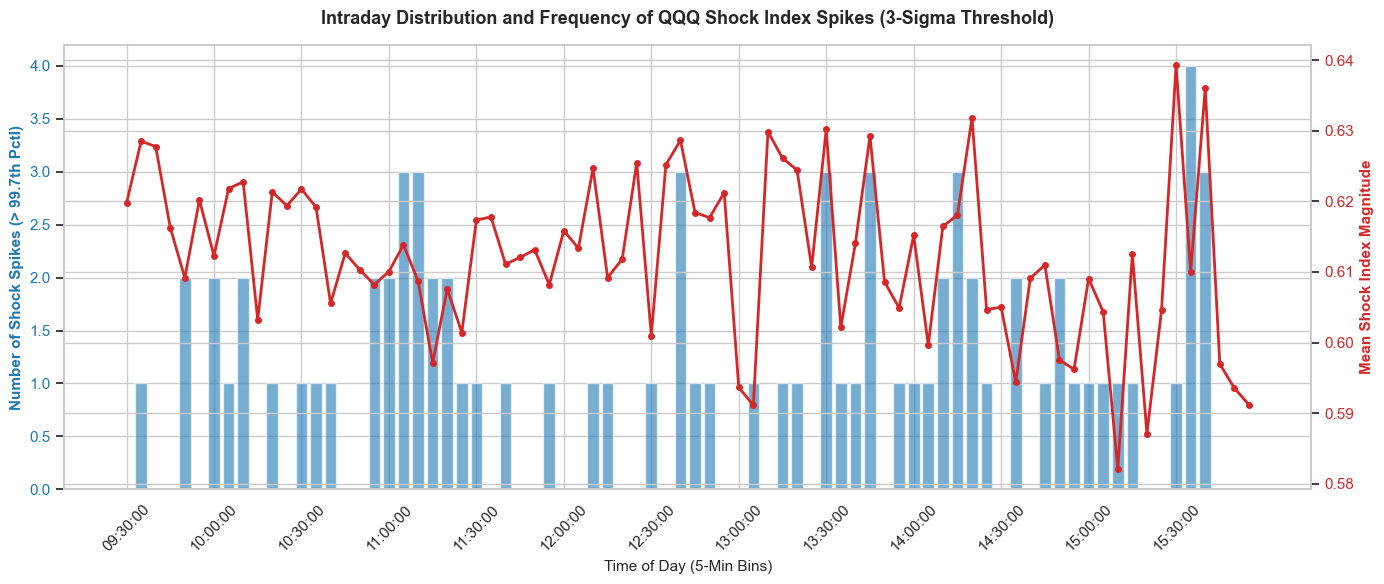

In [29]:
events_df.tail()# Ensure datetime is in the correct format
QQQ_processed['datetime'] = pd.to_datetime(QQQ_processed['datetime'])

# 1. Floor to the nearest 5-minute interval
QQQ_processed['5min_interval'] = QQQ_processed['datetime'].dt.floor('5min').dt.time

# 2. Define the new 99.7th percentile (3-Sigma) threshold
shock_threshold = QQQ_processed['shock_index'].quantile(0.997)

# 3. Aggregate by interval using the new 3-Sigma threshold
intraday_dist = QQQ_processed.groupby('5min_interval').agg(
    mean_shock=('shock_index', 'mean'),
    max_shock=('shock_index', 'max'),
    spike_count=('shock_index', lambda x: (x > shock_threshold).sum())
).reset_index()

# 4. Convert time objects to strings for cleaner plotting on the x-axis
intraday_dist['time_str'] = intraday_dist['5min_interval'].astype(str)

# 5. Filter for regular market hours (09:30 to 16:00)
market_hours = intraday_dist[
    (intraday_dist['5min_interval'] >= pd.to_datetime('09:30').time()) & 
    (intraday_dist['5min_interval'] <= pd.to_datetime('16:00').time())
]

# 6. Generate the dual-axis chart
fig, ax1 = plt.subplots(figsize=(14, 6))

# Plot 1: Frequency of spikes (Bar chart) - Now isolating 3-Sigma events
color = 'tab:blue'
ax1.set_xlabel('Time of Day (5-Min Bins)', fontsize=11)
ax1.set_ylabel('Number of Shock Spikes (> 99.7th Pctl)', color=color, fontsize=11, fontweight='bold')
bars = ax1.bar(market_hours['time_str'], market_hours['spike_count'], color=color, alpha=0.6)
ax1.tick_params(axis='y', labelcolor=color)

# Rotate x-labels and only show every 6th label (every 30 mins) to avoid crowding
ax1.set_xticks(market_hours['time_str'][::6]) 
ax1.tick_params(axis='x', rotation=45)

# Plot 2: Average intensity of shocks (Line chart)
ax2 = ax1.twinx()  
color = 'tab:red'
ax2.set_ylabel('Mean Shock Index Magnitude', color=color, fontsize=11, fontweight='bold')
ax2.plot(market_hours['time_str'], market_hours['mean_shock'], color=color, linewidth=2, marker='o', markersize=4)
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Intraday Distribution and Frequency of QQQ Shock Index Spikes (3-Sigma Threshold)', fontsize=13, fontweight='bold', pad=15)
fig.tight_layout()
plt.show()

Thankfully, there are no spikes at open nor close, which is one of the key issues I was afraid of.

In [31]:
#events_df.to_csv(r'events_identified_new_2.csv')

### Event classification

In [33]:
tweet_data['datetime'] = pd.to_datetime(tweet_data['New York Timestamp'], utc=True)
tweet_data['datetime'] = tweet_data['datetime'].dt.tz_convert('America/New_York')
tweet_data['datetime'] = tweet_data['datetime'].dt.tz_localize(None)

tweet_data['5min_interval'] = tweet_data['datetime'].dt.floor('5min').dt.time
tweet_data['date'] = tweet_data['datetime'].dt.date

raw_tweet_counts = tweet_data.groupby(['date', '5min_interval']).size().to_frame('raw_tweet_count').reset_index()

QQQ_processed['date'] = QQQ_processed['datetime'].dt.date
QQQ_processed['time'] = QQQ_processed['datetime'].dt.time

# safeguard
if 'raw_tweet_count' in QQQ_processed.columns:
    QQQ_processed = QQQ_processed.drop(columns=['raw_tweet_count'])

QQQ_processed = QQQ_processed.merge(
    raw_tweet_counts, 
    left_on=['date', 'time'], 
    right_on=['date', '5min_interval'], 
    how='left'
).fillna({'raw_tweet_count': 0})

if '5min_interval' in QQQ_processed.columns:
    QQQ_processed = QQQ_processed.drop(columns=['5min_interval'])

event_indices = QQQ_processed[QQQ_processed['is_event'] == True].index.tolist()

event_study_data = []
PRE_BARS = 6
POST_BARS = 12

for event_idx in event_indices:
    # Safeguard against boundary conditions at the very start/end of the historical dataset
    if event_idx < PRE_BARS or event_idx + POST_BARS >= len(QQQ_processed):
        continue
        
    event_row = QQQ_processed.loc[event_idx]
    event_id = f"{event_row['date']}_{event_row['time']}"
    
    # Calculate total raw tweets in the execution window (Bar T to Bar T+2)
    total_raw_tweets = QQQ_processed.loc[event_idx : event_idx + 2, 'raw_tweet_count'].sum()
    
    # Extract the full timeline slice from T-6 to T+12
    window_slice = QQQ_processed.loc[event_idx - PRE_BARS : event_idx + POST_BARS].copy()
    
    # Create the relative timeline index (-6 to +12)
    window_slice['relative_bar'] = np.arange(-PRE_BARS, POST_BARS + 1)
    window_slice['event_id'] = event_id
    window_slice['window_tweet_count'] = total_raw_tweets
    
    event_study_data.append(window_slice)

# Combine into the master panel dataframe
event_panel_df = pd.concat(event_study_data, ignore_index=True)

print(f"Successfully processed {event_panel_df['event_id'].nunique()} isolated event windows.")
print("\nSummary statistics of raw tweet counts within the (T to T+2) event windows:")
print(event_panel_df.groupby('event_id')['window_tweet_count'].first().describe())

Successfully processed 78 isolated event windows.

Summary statistics of raw tweet counts within the (T to T+2) event windows:
count    78.000000
mean      6.230769
std       6.100720
min       0.000000
25%       1.000000
50%       4.000000
75%      10.000000
max      23.000000
Name: window_tweet_count, dtype: float64


In [34]:
event_timestamps = QQQ_processed[QQQ_processed['is_event'] == True]['datetime'].sort_values().tolist()

isolated_tweets_pool = []

# --- STEP 3: Loop through each event with an explicit counter (1 to 93) ---
for i, event_time in enumerate(event_timestamps, start=1):
    
    # Expand the window: 5 minutes BEFORE the price shock to 10 minutes AFTER
    window_start = event_time - pd.Timedelta(minutes=5)
    window_end = event_time + pd.Timedelta(minutes=10)
    
    tweets_in_window = tweet_data[
        (tweet_data['datetime'] >= window_start) & 
        (tweet_data['datetime'] <= window_end)
    ].copy()
    
    if len(tweets_in_window) > 0:
        tweets_in_window['event_number'] = i
        tweets_in_window['market_shock_timestamp'] = event_time
        
        # Calculate minutes after (or before) the shock. 
        # Negative numbers mean the tweet dropped BEFORE the price shock!
        tweets_in_window['minutes_after_shock'] = (tweets_in_window['datetime'] - event_time).dt.total_seconds() / 60.0
        
        isolated_tweets_pool.append(tweets_in_window)

# --- STEP 4: Combine into your final inspection DataFrame ---
if isolated_tweets_pool:
    mapped_tweets_df = pd.concat(isolated_tweets_pool, ignore_index=True)
    
    # Reorganize columns to make it beautiful to read in your Jupyter Notebook
    # Adjust column names ('Text' / 'Source') to match your actual tweet_data columns
    text_col = 'text' if 'text' in mapped_tweets_df.columns else mapped_tweets_df.columns[1] 
    ordered_cols = ['event_number', 'market_shock_timestamp', 'datetime', 'minutes_after_shock', text_col]
    # Keep any other original columns present in tweet_data
    remaining_cols = [c for c in mapped_tweets_df.columns if c not in ordered_cols]
    
    mapped_tweets_df = mapped_tweets_df[ordered_cols + remaining_cols]
    
    print(f"✅ Successfully mapped {mapped_tweets_df['event_number'].nunique()} out of the events to raw tweets.")
    print(f"Total raw tweets captured across these windows: {len(mapped_tweets_df)}")
else:
    print("❌ No tweets found within the specified event windows. Double-check your timestamp formats.")

✅ Successfully mapped 69 out of the events to raw tweets.
Total raw tweets captured across these windows: 552


In [35]:
#mapped_tweets_df.to_csv(r'mapped_tweets_new_2.csv')

In [36]:
classified_events = pd.read_excel(r'C:\Users\Raymon\QF632/Project/Aryan/events_classified.xlsx')

### Event effects analyses

In his pivotal event study research paper in 1997, *Event Studies in Economics and Finance*, Craig Mackinlay explored the impact of economic or corporate event (like mergers, earnings announcements, or regulatory changes) on a firm's value, relying on the idea that market rationality will cause the effects to reflect immediately in security prices. Mackinlay uses Abnormal Returns and Cumulative Abnormal returns to assess the impact of his events.

However, with the sheer scale of modern financial markets today in terms of participants and the short horizons certain classes of investment firms, together with the ability for multiple events to occur in a day, assessing the impact on non-directional metrics: volatility and volume, may produce insights which are more monetisable than focusing on price. Therefore, I have decided to focus the study on volume and volatility. 

To account for intraday trading patterns, baseline levels are established by calculating the mean metric for each specific time of day ($t_{id}$) over a 20-day estimation window ($E$).

**1. Abnormal Metrics (per Event Time Step $\tau$)**

**Abnormal Volume ($AV_{\tau}$)**

Abnormal Volume measures the excess trading activity during the event window compared to what is typically expected for that specific asset at that exact time of day. A positive $AV$ means an influx of market participants and heightened liquidity consumption, signaling that the event is actively drawing market attention.

Volume is modeled using log differences, representing the percentage deviation from the expected time-of-day baseline:

$$AV_{\tau} = \ln(V_{\tau}) - \overline{\ln(V_{t_{id}})_{E}}$$

Where:
* $\ln(V_{\tau})$ is the log volume at event relative time step $\tau$.
* $\overline{\ln(V_{t_{id}})_{E}}$ is the average log volume for that specific time of day during the estimation window.

**Abnormal Volatility ($AVol_{\tau}$)**

Abnormal Volatility measures the excess price risk or uncertainty during the event window relative to what is typically expected for that specific asset at that exact time of day. A positive $AVol$ indicates that the event has triggered significant investor disagreement or rapid price discovery, causing wider price swings than normal for that time of day.

Volatility is calculated as the absolute difference in raw Parkinson standard deviations, scaled by an annualization factor to represent annualized percentage terms:

$$AVol_{\tau} = \left( \sigma_{\tau}^{Park} - \overline{\sigma_{t_{id}}^{Park}}_{E} \right) \times A$$

Where:
* $\sigma_{\tau}^{Park}$ is the raw Parkinson volatility at event relative time step $\tau$.
* $\overline{\sigma_{t_{id}}^{Park}}_{E}$ is the baseline mean Parkinson volatility for that time of day.
* $A$ is the annualization factor, defined by the number of 5-minute bars per day (78) and trading days per year (252):

$$A = \sqrt{78 \times 252} \times 100$$

---

**2. Cumulative Metrics**

The cumulative indicators track the total distortion in volume and volatility across the event horizon, summing from the start of the event window ($\tau = -1$) up to the current horizon $T$.

**Cumulative Abnormal Volume ($CAV$)**

$$CAV_{T} = \sum_{\tau = -1}^{T} AV_{\tau}$$

**Cumulative Abnormal Volatility ($CAVol$)**

$$CAVol_{T} = \sum_{\tau = -1}^{T} AVol_{\tau}$$

In [40]:
# just in case
QQQ_5min = pd.read_csv(r'C:\Users\Raymon\QF632/Project/Aryan/fds-indx-data/indx_data/QQQ_5min.csv')
QQQ_5min = delete_ghost_rows(QQQ_5min)
QQQ_processed = compute_market_shocks(QQQ_5min)

🧹 Purged exactly 216 ghost rows (including the 13:00:00 bars) across the timeline.


#### Event effects: 1 hour after event

In [42]:
# Ensure datetimes are formatted across both datasets
QQQ_processed['datetime'] = pd.to_datetime(QQQ_processed['datetime'])
classified_events['datetime'] = pd.to_datetime(classified_events['datetime'])

# Pre-calculate a clean time string identifier to handle the time-of-day matching
QQQ_processed['time_id'] = QQQ_processed['datetime'].dt.time

# Scaling factor to convert 5-minute Parkinson standard deviations to Annualized Volatility %
# 78 five-minute bars per day * 252 trading days per year
ANNUALIZATION_FACTOR = np.sqrt(78 * 252) * 100

panel_records = []

for idx, event_row in classified_events.iterrows():
    t_zero = event_row['datetime']
    event_class = event_row['classification']
    
    # 1. Find the exact position index of T_0 in your master price series
    master_matches = QQQ_processed[QQQ_processed['datetime'] == t_zero]
    if master_matches.empty:
        continue
    t_zero_idx = master_matches.index[0]
    
    # 2. Slice the Event Window: 1 bar before to 12 bars after (Total 14 bars)
    # Using .loc with integer indexing based on the master dataframe index order
    try:
        event_window = QQQ_processed.loc[t_zero_idx - 1 : t_zero_idx + 12].copy()
    except KeyError:
        # Catch edge cases near the absolute boundaries of the dataframe
        continue
        
    if len(event_window) < 14:
        continue # Skip if window is clipped by missing data
        
    # 3. Establish the 20-Day Estimation Window Pool
    # We look back roughly 20 trading days (20 days * 78 bars/day = ~1560 bars) prior to the event
    start_est_idx = max(0, t_zero_idx - 1560)
    end_est_idx = t_zero_idx - 2 # Stop right before the event window starts
    
    estimation_pool = QQQ_processed.loc[start_est_idx : end_est_idx]
    
    # 4. Compute Diurnal (Time-of-Day) Baselines
    # This averages out the morning/afternoon volume & volatility smile curves
    tod_baseline = estimation_pool.groupby('time_id')[['log_volume', 'park_vol_raw']].mean().reset_index()
    tod_baseline.columns = ['time_id', 'base_log_vol', 'base_park_raw']
    
    # Merge baselines back into the tracking window
    event_window = event_window.merge(tod_baseline, on='time_id', how='left')
    
    # 5. Compute Abnormal Metrics
    # Volume: Log difference = Percentage deviation from normal time-of-day volume
    event_window['abnormal_volume'] = event_window['log_volume'] - event_window['base_log_vol']
    
    # Volatility: Absolute difference in raw variance scaled to annualized percentages
    event_window['abnormal_volatility'] = (event_window['park_vol_raw'] - event_window['base_park_raw']) * ANNUALIZATION_FACTOR
    
    # 6. Generate the Relative Event Time Step Axis (tau = -1, 0, 1, ..., 12)
    event_window['event_time_step'] = np.arange(-1, len(event_window) - 1)
    
    # 7. Compute Cumulative Indicators across the Event Horizon
    event_window['CAV'] = event_window['abnormal_volume'].cumsum()
    event_window['CAVol'] = event_window['abnormal_volatility'].cumsum()
    
    # Metadata tagging for grouping later
    event_window['event_id'] = t_zero
    event_window['classification'] = event_class
    
    # Keep only the columns necessary for structural analysis to save memory
    clean_window = event_window[[
        'event_id', 'classification', 'event_time_step', 
        'abnormal_volume', 'CAV', 'abnormal_volatility', 'CAVol'
    ]]
    
    panel_records.append(clean_window)

# Combine into a rigorous master analysis panel dataframe
df_event_study_panel = pd.concat(panel_records, ignore_index=True)
print(f"✅ Panel constructed successfully! Total observations: {len(df_event_study_panel)}")

✅ Panel constructed successfully! Total observations: 1092


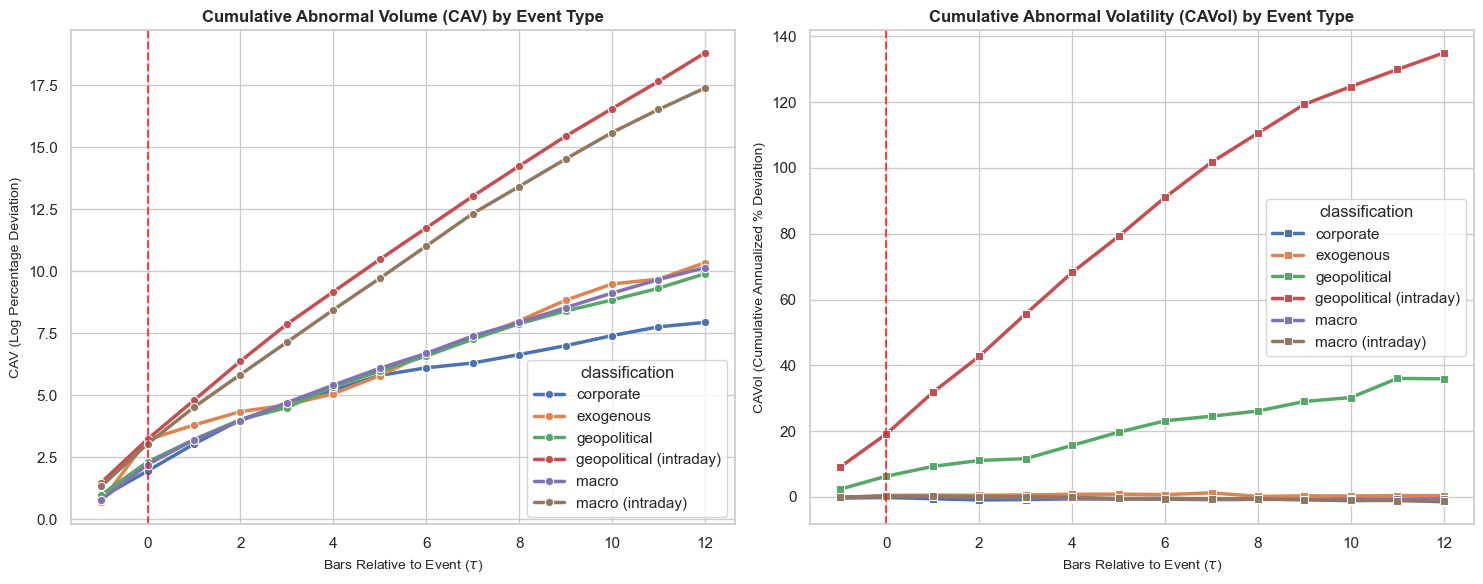

In [43]:
# Compute the mean vectors across categories
df_results = df_event_study_panel.groupby(['classification', 'event_time_step']).mean().reset_index()

# Set up a beautiful 2-panel figure for your thesis document
fig, ax = plt.subplots(1, 2, figsize=(15, 6))
sns.set_theme(style="whitegrid")

# Left Plot: Cumulative Abnormal Volume (CAV)
sns.lineplot(
    data=df_results, x='event_time_step', y='CAV', 
    hue='classification', marker='o', linewidth=2.5, ax=ax[0]
)
ax[0].axvline(x=0, color='red', linestyle='--', alpha=0.7)
ax[0].set_title("Cumulative Abnormal Volume (CAV) by Event Type", fontsize=12, fontweight='bold')
ax[0].set_xlabel("Bars Relative to Event ($\\tau$)", fontsize=10)
ax[0].set_ylabel("CAV (Log Percentage Deviation)", fontsize=10)

# Right Plot: Cumulative Abnormal Volatility (CAVol)
sns.lineplot(
    data=df_results, x='event_time_step', y='CAVol', 
    hue='classification', marker='s', linewidth=2.5, ax=ax[1]
)
ax[1].axvline(x=0, color='red', linestyle='--', alpha=0.7)
ax[1].set_title("Cumulative Abnormal Volatility (CAVol) by Event Type", fontsize=12, fontweight='bold')
ax[1].set_xlabel("Bars Relative to Event ($\\tau$)", fontsize=10)
ax[1].set_ylabel("CAVol (Cumulative Annualized % Deviation)", fontsize=10)

plt.tight_layout()
plt.show()

**Cumulative Abnormal Volume**

- Cumulative abnormal volume begins climbing before the event begins across all event types, which could signal that across all event types, there could be private leakage of information, resulting in institutional execution algorithms or insiders trading on private order flow imbalances.
- Cumulative abnormal volume keeps rising one hour after the event, indicating that all event classes have a material and lasting impact on trading volume.


**Cumulative Abnormal Volatility**

- Only the geopolitical events display a positive cumulative abnormal volatility 1 period before the events.
- Only the geopolitical events appear to have a lasting impact on volatility into the hour after the event, indicating that the implications of other events have been more quickly priced in, resulting in insignificant abnormal volume 1 hour into the event. This could be because there are explicit numbers that can be connected to macroeconomic, corporate etc. events, which make them more digestible for financial models. However, the implications of geopolitical events are not straightforward, especially on such as short horizon

#### Event effects: 3 hours after event

In [46]:
# Ensure datetimes match perfectly across both structures
QQQ_processed['datetime'] = pd.to_datetime(QQQ_processed['datetime'])
classified_events['datetime'] = pd.to_datetime(classified_events['datetime'])

# Pre-calculate a clean time string identifier to handle time-of-day matching
QQQ_processed['time_id'] = QQQ_processed['datetime'].dt.time

# Scaling factor to convert 5-minute Parkinson standard deviations to Annualized Volatility %
ANNUALIZATION_FACTOR = np.sqrt(78 * 252) * 100

panel_records = []

for idx, event_row in classified_events.iterrows():
    t_zero = event_row['datetime']
    event_class = event_row['classification']
    
    # Locate the position index of T_0 in your master price series
    master_matches = QQQ_processed[QQQ_processed['datetime'] == t_zero]
    if master_matches.empty:
        continue
    t_zero_idx = master_matches.index[0]
    
    # EXTENDED: Slice the Event Window from 1 bar before to 36 bars after (Total 38 bars)
    try:
        event_window = QQQ_processed.loc[t_zero_idx - 1 : t_zero_idx + 36].copy()
    except KeyError:
        continue
        
    # Ensure the window is fully intact (not clipped by the absolute ends of the dataset)
    if len(event_window) < 38:
        continue 
        
    # Establish the 20-Day Estimation Window Pool (~1560 bars back)
    start_est_idx = max(0, t_zero_idx - 1560)
    end_est_idx = t_zero_idx - 2 
    
    estimation_pool = QQQ_processed.loc[start_est_idx : end_est_idx]
    
    # Compute Diurnal Baselines
    tod_baseline = estimation_pool.groupby('time_id')[['log_volume', 'park_vol_raw']].mean().reset_index()
    tod_baseline.columns = ['time_id', 'base_log_vol', 'base_park_raw']
    
    # Merge baselines back into the tracking window
    event_window = event_window.merge(tod_baseline, on='time_id', how='left')
    
    # Compute Abnormal Metrics
    event_window['abnormal_volume'] = event_window['log_volume'] - event_window['base_log_vol']
    event_window['abnormal_volatility'] = (event_window['park_vol_raw'] - event_window['base_park_raw']) * ANNUALIZATION_FACTOR
    
    # Relative time step axis (tau = -1, 0, 1, ..., 36)
    event_window['event_time_step'] = np.arange(-1, len(event_window) - 1)
    
    # Compute Cumulative Profiles
    event_window['CAV'] = event_window['abnormal_volume'].cumsum()
    event_window['CAVol'] = event_window['abnormal_volatility'].cumsum()
    
    # OPTIONAL/BEST PRACTICE: Re-zero the cumulative tracking so that tau = -1 begins at exactly 0.0
    event_window['CAV'] = event_window['CAV'] - event_window.iloc[0]['CAV']
    event_window['CAVol'] = event_window['CAVol'] - event_window.iloc[0]['CAVol']
    
    # Metadata tagging for panel grouping
    event_window['event_id'] = t_zero
    event_window['classification'] = event_class
    
    clean_window = event_window[[
        'event_id', 'classification', 'event_time_step', 
        'abnormal_volume', 'CAV', 'abnormal_volatility', 'CAVol'
    ]]
    
    panel_records.append(clean_window)

# Combine into the extended master panel
df_event_study_panel_36 = pd.concat(panel_records, ignore_index=True)
print(f"✅ Extended panel constructed successfully! Total observations: {len(df_event_study_panel_36)}")

✅ Extended panel constructed successfully! Total observations: 2964


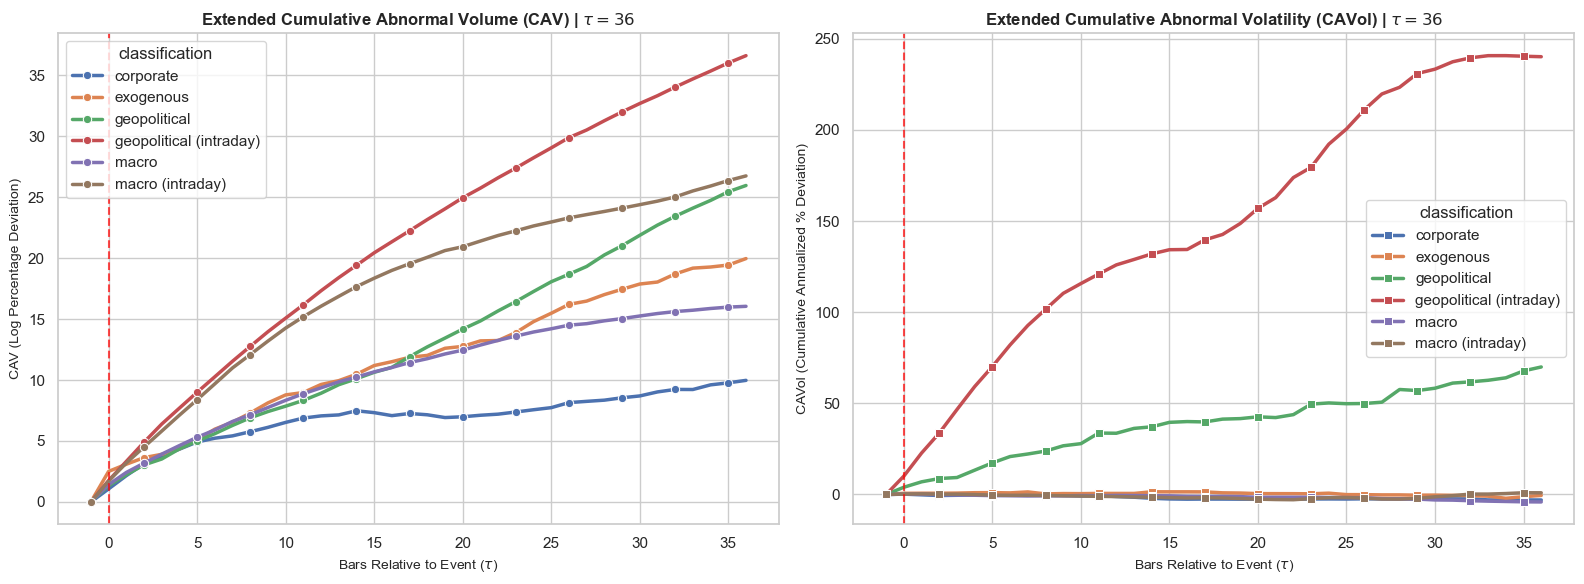

In [47]:
# Compute cross-sectional means across the extended time steps
df_results_36 = df_event_study_panel_36.groupby(['classification', 'event_time_step']).mean().reset_index()

fig, ax = plt.subplots(1, 2, figsize=(16, 6))
sns.set_theme(style="whitegrid")

# Left Panel: Extended CAV
sns.lineplot(
    data=df_results_36, x='event_time_step', y='CAV', 
    hue='classification', marker='o', markevery=3, linewidth=2.5, ax=ax[0]
)
ax[0].axvline(x=0, color='red', linestyle='--', alpha=0.7)
ax[0].set_title("Extended Cumulative Abnormal Volume (CAV) | $\\tau = 36$", fontsize=12, fontweight='bold')
ax[0].set_xlabel("Bars Relative to Event ($\\tau$)", fontsize=10)
ax[0].set_ylabel("CAV (Log Percentage Deviation)", fontsize=10)

# Right Panel: Extended CAVol
sns.lineplot(
    data=df_results_36, x='event_time_step', y='CAVol', 
    hue='classification', marker='s', markevery=3, linewidth=2.5, ax=ax[1]
)
ax[1].axvline(x=0, color='red', linestyle='--', alpha=0.7)
ax[1].set_title("Extended Cumulative Abnormal Volatility (CAVol) | $\\tau = 36$", fontsize=12, fontweight='bold')
ax[1].set_xlabel("Bars Relative to Event ($\\tau$)", fontsize=10)
ax[1].set_ylabel("CAVol (Cumulative Annualized % Deviation)", fontsize=10)

plt.tight_layout()
plt.show()

The results are largely an extension of what has been observed in the one hour window.

**Cumulative Abnormal Volume**

- Macroeconomic events begin tapering off faster than geopolitical events. CAV of non-intraday geopolitical events even begin accelerating 3 hours in.

#### Quantifying the slopes: Pooled Ordinary Least Squares Regression

To further quantify these effects, I have fitted a Pooled OLS Regression to the post shock window from t = 5 to t = 36. This explicitly quantifies the slope of the cumulative drift for each event category.

The regression will take the form:

$$\text{Metric}_{i,\tau} = \beta_0 + \beta_1 \tau + \epsilon_{i,\tau}$$

This model will be used for each metric separately, on each event classification separately. Thus, the interpretation should be how much of the variation in a particular metric past the event duration can be explained simply by passage of time. This explores the lasting impact of each category of event on the metric in the medium term after the event. 

**Financial timeseries complications:**

- High autocorrelation in high to medium frequency data: 32 sequential 5-minute intervals inside a single event window are highly serially correlated. This will result in the standard errors of the beta coefficients being understated, and hence artificially inflated t-statistics. This obscures the true impact of the events on drift in CAV and CAVol.
- Heteroskedasticity: In financial timeseries data, the variance of the residuals is not constant across time or categories. This is expected in our dataset as 1) we expect different classes of events to have different effects on CAV and CAVol (intuitively, a geopolitical event should spark a larger swing in abnormal volatility than a routine, scheduled Corporate earnings announcement). 2) The raw data is timeseries data, the residual variance right after the shock ($\tau = 5$) is expected to be more volatile than the residual variance hours later ($\tau = 36$), where the market has settled.

**Mitigations using regression architecture**

- Cluster robust estimation: The model clusters the data by event id, allowing arbitrary, unrestricted correlation structures inside each event window, hence assuming that a particular event is independent of another event that occurs days or month later. Since standard OLS assumes all observations are independent, this clustering method renders events as independent, allowing OLS to be carried out without underestimating the true standard errors. 
- Huber-White Heteroskedasticity-Consistent standard errors: By using this feature, the model does not assume constant variance for each obervation of the error term. It instead squares the individual clusters residual vector directly inside the core of the sandwich matrix, scaling the standard errors up or down to match the actual dispersion of that specific event category. This statistically groups the observations by individual historical event dates, correcting for serial dependence and hence yielding more statistically robust p-values.
- Single predictor: Since the model has time elapsed as the only independent explanatory variable, there are no other competing independent variables that will cause multicollinearity. A separate OLS model is run separately on CAV and CAVol, on each event classification. This is typically done through using a categorical variable, which would use one event class as the baseline to avoid perfect multicollinearity.

In [51]:
# 1. Filter for the post-event drift window (from 25 mins out to 3 hours out)
df_reg_window = df_event_study_panel_36[
    (df_event_study_panel_36['event_time_step'] >= 5) & 
    (df_event_study_panel_36['event_time_step'] <= 36)
].copy()

regression_outputs = []

# 2. Iterate through both metrics and all event classifications
for metric in ['CAVol', 'CAV']:
    for category, group_df in df_reg_window.groupby('classification'):
        
        # Fit OLS: Metric = Beta_0 + Beta_1 * event_time_step
        model = smf.ols(f"{metric} ~ event_time_step", data=group_df)
        
        # CRITICAL ETHICAL CORRECTION: Cluster standard errors at the unique event_id level
        # This handles intra-event serial correlation across the 5-minute intervals
        fitted_model = model.fit(
            cov_type='cluster', 
            cov_kwds={'groups': group_df['event_id']}
        )
        
        # Extract relevant econometric parameters
        beta_1 = fitted_model.params['event_time_step']
        std_err = fitted_model.bse['event_time_step']
        t_stat = fitted_model.tvalues['event_time_step']
        p_value = fitted_model.pvalues['event_time_step']
        r_squared = fitted_model.rsquared
        n_obs = int(fitted_model.nobs)
        
        regression_outputs.append({
            'Metric': metric,
            'Classification': category,
            'Slope (Beta_1)': beta_1,
            'Robust SE': std_err,
            't-statistic': t_stat,
            'p-value': p_value,
            'R-squared': r_squared,
            'N (Obs)': n_obs
        })

# 3. Transform into a polished summary panel
df_regression_results = pd.DataFrame(regression_outputs)

print("\n==========================================================================")
print("     ECONOMETRIC ESTIMATION TABLE: POST-SHOCK DRIFT DRIFT (tau = 5 to 36) ")
print("==========================================================================")
print(df_regression_results.to_string(index=False, formatters={
    'Slope (Beta_1)': '{:,.4f}'.format,
    'Robust SE': '{:,.4f}'.format,
    't-statistic': '{:,.2f}'.format,
    'p-value': '{:,.4f}'.format,
    'R-squared': '{:,.4f}'.format,
    'N (Obs)': '{:,}'.format
}))


     ECONOMETRIC ESTIMATION TABLE: POST-SHOCK DRIFT DRIFT (tau = 5 to 36) 
Metric          Classification Slope (Beta_1) Robust SE t-statistic p-value R-squared N (Obs)
 CAVol               corporate        -0.0847    0.0531       -1.60  0.1107    0.2185      96
 CAVol               exogenous        -0.0711    0.1075       -0.66  0.5084    0.0174      96
 CAVol            geopolitical         1.5175    0.7297        2.08  0.0376    0.0375     416
 CAVol geopolitical (intraday)         5.7571    2.3301        2.47  0.0135    0.0378     640
 CAVol                   macro        -0.1141    0.0492       -2.32  0.0203    0.0276     800
 CAVol        macro (intraday)         0.0175    0.0723        0.24  0.8087    0.0009     448
   CAV               corporate         0.1318    0.1658        0.79  0.4268    0.0672      96
   CAV               exogenous         0.4653    0.1095        4.25  0.0000    0.4936      96
   CAV            geopolitical         0.6949    0.0850        8.17  0.0000   

**Observations for CAVol**

Beta coefficients:

- As hypothesised, geopolitical events have the highest Beta coefficients, indicating that geopolitical events (intraday geopolitical events in particular), on average, cause the highest lasting impact on volatility following events.
- In comparison, the other events have beta coefficients an order lower than that of geopolitical events.

p-value (5% significance level):

- Only geopolitical events (intraday and non-intraday) and non-intraday macroeconomic events have statistically significant impact on volatility up till 3h after the event.

R-squared:

- Across categories, the general R-squared is not high, indicating that there are more factors besides passage of time that determine the variation of volatility up till 3h after the event.

 **Observations for CAV**

Beta coefficients:

- Again, geopolitical events have the highest Beta coefficients, indicating that geopolitical events (intraday geopolitical events in particular), on average, cause the highest lasting impact on volume following events.
- In general, the events are closer to each other in impact on Volume than in Volatility.
  
p-value (5% significance level):

- All beta coefficients are statistically significant besides corporate events.
 
R-squared:

- Across categories, the general R-squared is higher in comparison to that of CAVol, indicating that the variation in volume is more explainable by passage of time than volatility.
- R-square values are still mostly below 0.5 (except exogenous which is a catch all category for unclassifiable events), indicating that there are more factors besides passage of time that determine the variation of volume up till 3h after the event.

## Takeaways

- **Volatility expansion post geopolitical events**: When an unexpected geopolitical shock drops during market hours, volatility expands monotonically for at least 3 hours. Post geopolitical event price discovery is continuous, structural, and sustained. Thus, market makers should instantly widen bid-ask spreads significantly or pull back limit order depth entirely. Additionally, directional momentum traders are justified in chasing the breakout, as information is not digested in a single 5-minute bar.
- **Peak uncertainty in macroeconomic events**: For standard macro events, the peak uncertainty happens at the announcement ($\tau = 0$). Once the number hits the tape, information asymmetry clears out almost immediately.  Market makers can aggressively step in 25 minutes after the announcement ($\tau = 5$) to sell premium. They can also tighten market-making spreads back to normal, and provision deeper liquidity. The market returns to baseline equilibrium systematically as time passes.
- **Volume explosion post events**: Volume cascades relentlessly over the next 3 hours across all event categories rather than vanishing. Institutional traders looking to execute massive block orders can do so knowing that market liquidity/turnover is vast enough to absorb large sizes.
- **Sentiment analyses for live event classification**: Sentiment analyses should be done live to classify the events to diagnose the probable impacts of each event. Despite the complexity of AI, I still had to check its classifications and notes against the logged tweets, hence human monitoring the algorithms is still ideal.
- **Non-stationarity of markets**: The study was done on 2 years worth of data. Financial markets are always evolving, and so does the impact of different classes of events on volatility and volume. As markets become faster and more efficient, the effects can change drastically Ideally, the study should cross many regimes and effects should be sliced across regime periods.